# CS171 Final Project: 27-Class Sign Language Recognition

**Dataset:** [27 Class Sign Language Dataset](https://www.kaggle.com/datasets/ardamavi/27-class-sign-language-dataset/data) - 4,671 images × 27 classes  
**Goal:** Train a custom CNN to classify ASL hand gestures; benchmark against ResNet50  

---
**Sections**
1. Setup & Imports
2. Load Dataset
3. Data Exploration
4. Preprocessing
5. Custom CNN Model
6. ResNet50 Baseline
7. Training
8. Evaluation
9. Inference on User Image

## 1. Setup & Imports

In [15]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(Y_raw.flatten())

print("Classes:", le.classes_)
print("y shape:", y.shape)
print("Sample labels:", y[:5])

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Config
IMG_SIZE = 128
NUM_CLASSES = 27
BATCH_SIZE = 16
EPOCHS = 20

CLASS_NAMES = [
    '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'NULL', 'a', 'b', 'bye', 'c', 'd', 'e',
    'good', 'good morning', 'hello', 'little bit', 'no', 'pardon', 'please',
    'project', 'whats up', 'yes'
 ]

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("CPU:", tf.config.list_physical_devices("CPU"))

Classes: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'NULL' 'a' 'b' 'bye' 'c' 'd' 'e'
 'good' 'good morning' 'hello' 'little bit' 'no' 'pardon' 'please'
 'project' 'whats up' 'yes']
y shape: (22801,)
Sample labels: [23 23 23 23 23]
TF version: 2.21.0
GPU: []
CPU: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## 2. Load Dataset

In [3]:
X_raw = np.load("data/X.npy")   # (N, 64, 64, 3)  float32  [0, 1]
Y_raw = np.load("data/Y.npy")   # (N, 27)          float32  one-hot

print("X shape:", X_raw.shape)
print("Y shape:", Y_raw.shape)
print("Pixel range: [{:.3f}, {:.3f}]".format(X_raw.min(), X_raw.max()))

X shape: (22801, 128, 128, 3)
Y shape: (22801, 1)
Pixel range: [0.000, 1.000]


## 3. Data Exploration

In [4]:
# finding null datapoints
for i in range(22801):
    if Y_raw[i][0] == "NULL":
        print(i)

10594
10595
10596
10597
10598
10599
10600
10601
10602
10603
10604
10605
10606
10607
10608
10609
10610
10611
10612
10613
10614
10615
10616
10617
10618
10619
10620
10621
10622
10623
10624
10625
10626
10627
10628
10629
10630
10631
10632
10633
10634
10635
10636
10637
10638
10639
10640
10641
10642
10643
10644
10645
10646
10647
10648
10649
10650
10651
10652
10653
10654
10655
10656
10657
10658
10659
10660
10661
10662
10663
10664
10665
10666
10667
10668
10669
10670
10671
10672
10673
10674
10675
10676
10677
10678
10679
10680
10681
10682
10683
10684
10685
10686
10687
10688
10689
10690
10691
10692
10693
10694
10695
10696
10697
10698
10699
10700
10701
10702
10703
10704
10705
10706
10707
10708
10709
10710
10711
10712
10713
10714
10715
10716
10717
10718
10719
10720
10721
10722
10723
10724
10725
10726
10727
10728
10729
10730
10731
10732
10733
10734
10735
10736
10737
10738
10739
10740
10741
10742
10743
10744
10745
10746
10747
10748
10749
10750
10751
10752
10753
10754
10755
10756
10757
10758
10759
1076

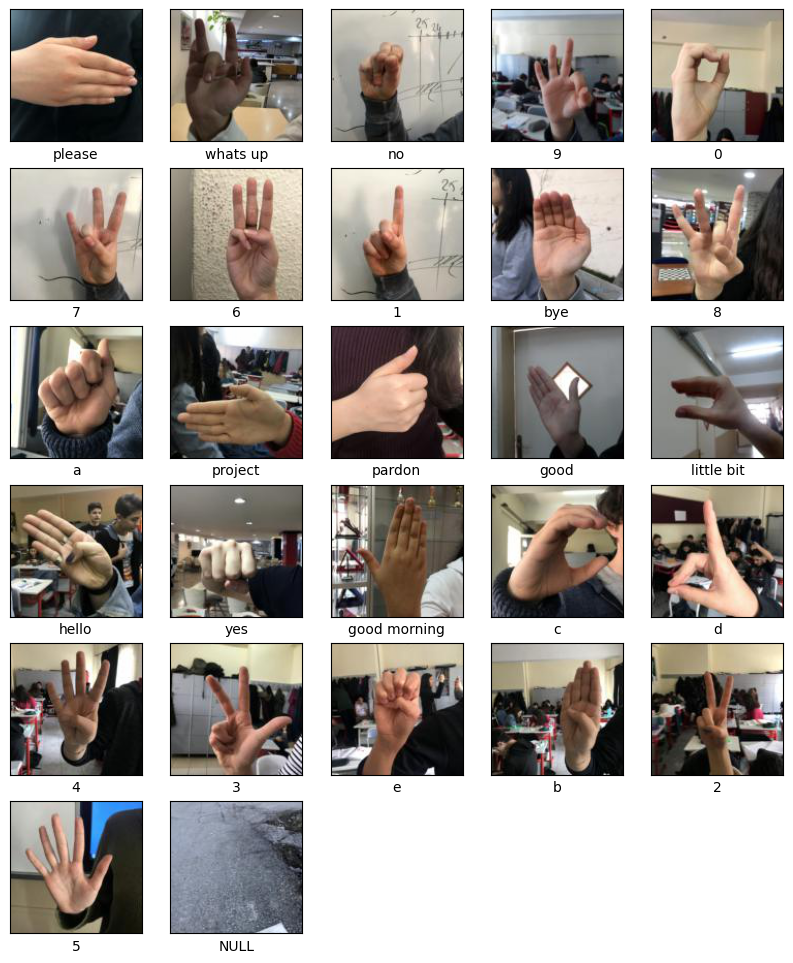

In [5]:
import matplotlib.pyplot as plt
# shows image of each hand gesture
plt.figure(figsize=(10,12))
for i in range(0, 27):
    plt.subplot(6,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    if i == 26: # for null
        plt.imshow(X_raw[10600])
        plt.xlabel(Y_raw[10600][0])
    else:
        plt.imshow(X_raw[(i+1)*800])
        plt.xlabel(Y_raw[(i+1)*800][0])

plt.show()

## 4. Preprocessing

Steps per proposal:
1. Resize to 128×128
2. Convert to grayscale
3. Normalize to [0, 1]
4. Train / val / test split (70 / 10 / 20)

In [9]:
X = tf.image.rgb_to_grayscale(X_raw)
X = X.numpy()

print("Processed X shape:", X.shape)   # (N,128,128,1)
print("Pixel range:", X.min(), "to", X.max())


Processed X shape: (22801, 128, 128, 1)
Pixel range: 0.0 to 0.99990004


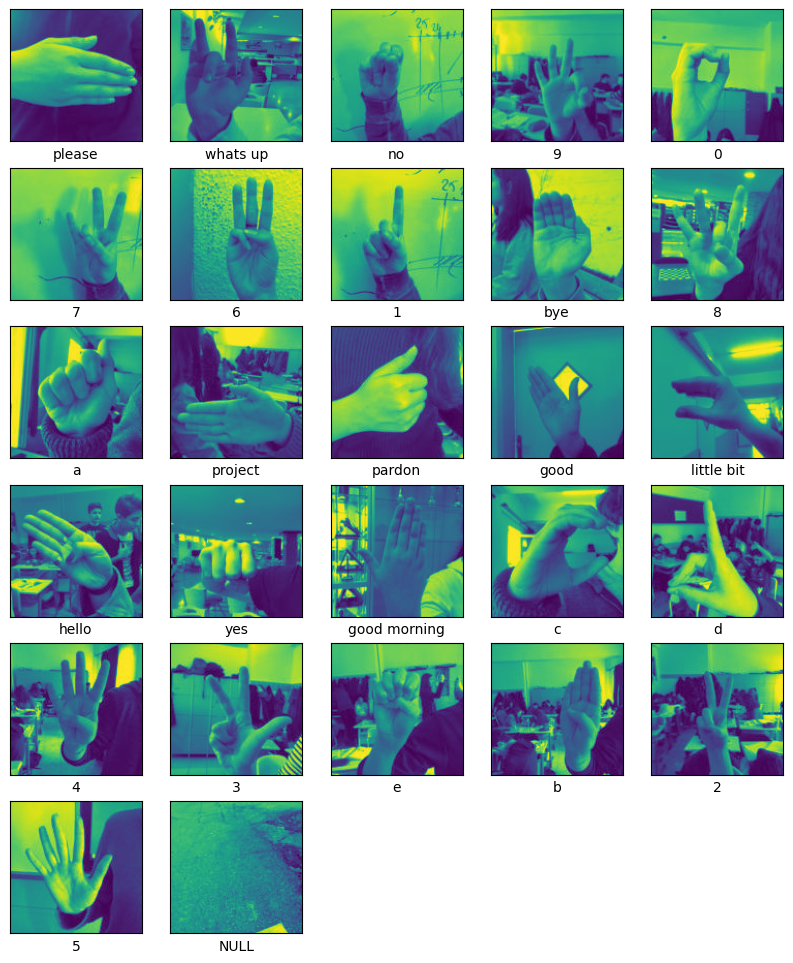

In [21]:
plt.figure(figsize=(10,12))
for i in range(0, 27):
    plt.subplot(6,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    if i == 26: # for null
        plt.imshow(X[10600])
        plt.xlabel(Y_raw[10600][0])
    else:
        plt.imshow(X[(i+1)*800])
        plt.xlabel(Y_raw[(i+1)*800][0])

plt.show()

## 5. Custom CNN Model

Architecture: Conv → ReLU → MaxPool (repeated) → Flatten → Dense → Softmax  
Input: 128×128×1 grayscale

In [ ]:
le = LabelEncoder()
y = le.fit_transform(Y_raw.flatten())  # converts strings -> integers

print("Classes:", le.classes_)  # so we can see the mapping
print("y shape:", y.shape)
print("Sample labels:", y[:5])
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.125, random_state=SEED, stratify=y_tv
)

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")

Classes: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'NULL' 'a' 'b' 'bye' 'c' 'd' 'e'
 'good' 'good morning' 'hello' 'little bit' 'no' 'pardon' 'please'
 'project' 'whats up' 'yes']
y shape: (22801,)
Sample labels: [23 23 23 23 23]
Train : (15960, 128, 128, 1)
Val   : (2280, 128, 128, 1)
Test  : (4561, 128, 128, 1)


In [17]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128, 128, 1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax'),
], name='custom_cnn')

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 27)             │         6,939 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,488,475 (32.38 MB)

 Trainable params: 8,488,475 (32.38 MB)

 Non-trainable params: 0 (0.00 B)

## 6. ResNet50 Baseline

ResNet50 expects 3-channel RGB input — we'll repeat the grayscale channel × 3.

## 7. Training

In [18]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ]
)

Epoch 1/20
998/998 ━━━━━━━━━━━━━━━━━━━━ 749s 749ms/step - accuracy: 0.2552 - loss: 2.5311 - val_accuracy: 0.5807 - val_loss: 1.4681
Epoch 2/20
998/998 ━━━━━━━━━━━━━━━━━━━━ 237s 237ms/step - accuracy: 0.5779 - loss: 1.3340 - val_accuracy: 0.6811 - val_loss: 1.0418
Epoch 3/20
998/998 ━━━━━━━━━━━━━━━━━━━━ 203s 204ms/step - accuracy: 0.7121 - loss: 0.9032 - val_accuracy: 0.7184 - val_loss: 0.9713
Epoch 4/20
998/998 ━━━━━━━━━━━━━━━━━━━━ 200s 200ms/step - accuracy: 0.7900 - loss: 0.6510 - val_accuracy: 0.7412 - val_loss: 0.9052
Epoch 5/20
998/998 ━━━━━━━━━━━━━━━━━━━━ 205s 206ms/step - accuracy: 0.8419 - loss: 0.4803 - val_accuracy: 0.7425 - val_loss: 0.9258
Epoch 6/20
998/998 ━━━━━━━━━━━━━━━━━━━━ 205s 206ms/step - accuracy: 0.8798 - loss: 0.3585 - val_accuracy: 0.7570 - val_loss: 0.9493
Epoch 7/20
998/998 ━━━━━━━━━━━━━━━━━━━━ 198s 199ms/step - accuracy: 0.9000 - loss: 0.3056 - val_accuracy: 0.7627 - val_loss: 0.9449
Epoch 8/20
998/998 ━━━━━━━━━━━━━━━━━━━━ 197s 197ms/step - accuracy: 0.9132 -

History keys: dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
Sample history: {'accuracy': [0.25520050525665283, 0.5778822302818298, 0.7120927572250366, 0.7900375723838806, 0.8418546319007874], 'loss': [2.531071424484253, 1.3340089321136475, 0.9031950235366821, 0.6509869694709778, 0.4803059697151184], 'val_accuracy': [0.5807017683982849, 0.6811403632164001, 0.7184210419654846, 0.7412280440330505, 0.7425438761711121], 'val_loss': [1.4681495428085327, 1.0417619943618774, 0.9713418483734131, 0.9051720499992371, 0.9257734417915344]}


## 8. Evaluation

## 9. Inference on User Image